In [ ]:
# Notebook 04: Deep Learning for Heart Disease Prediction

In [ ]:
## Introduction

This notebook develops a Deep Learning model for binary heart disease prediction using the preprocessed Cleveland Heart Disease dataset.
The objective is to evaluate whether a neural network can improve predictive performance compared with the classical machine learning models
developed in Notebook 03.

The model is implemented using TensorFlow/Keras and evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC.

In [ ]:
## Objectives

- Load the preprocessed training and testing datasets.
- Build a Deep Neural Network using TensorFlow/Keras.
- Train the model using early stopping.
- Evaluate model performance.
- Generate visualisations.
- Save the trained model.
- Compare results with classical machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
PROCESSED_PATH = DATA_PATH / "processed"

MODEL_PATH = PROJECT_ROOT / "models"
FIGURES_PATH = PROJECT_ROOT / "Figures"
RESULTS_PATH = PROJECT_ROOT / "results"

MODEL_PATH.mkdir(exist_ok=True)
FIGURES_PATH.mkdir(exist_ok=True)
RESULTS_PATH.mkdir(exist_ok=True)

In [ ]:
## Model Architecture

The neural network consists of two hidden layers with ReLU activation functions and dropout regularisation to reduce overfitting.
A sigmoid output layer is used because this is a binary classification problem.

In [3]:
train = pd.read_csv(PROCESSED_PATH / "heart_train_processed.csv")
test = pd.read_csv(PROCESSED_PATH / "heart_test_processed.csv")

In [4]:
X_train = train.drop(columns="target")
y_train = train["target"]

X_test = test.drop(columns="target")
y_test = test["target"]

print(X_train.shape)
print(X_test.shape)

(242, 13)
(61, 13)


In [ ]:
## Model Evaluation

The trained model is evaluated using the unseen test dataset. Multiple evaluation metrics are used to provide
a comprehensive assessment of predictive performance.

In [6]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Input(shape=(13,)),

    Dense(32, activation="relu"),
    Dropout(0.30),

    Dense(16, activation="relu"),
    Dropout(0.20),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5026 - loss: 0.7908 - val_accuracy: 0.5510 - val_loss: 0.6646
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5440 - loss: 0.7073 - val_accuracy: 0.7143 - val_loss: 0.6178
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6477 - loss: 0.6432 - val_accuracy: 0.7755 - val_loss: 0.5885
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6788 - loss: 0.6247 - val_accuracy: 0.7551 - val_loss: 0.5703
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7358 - loss: 0.5734 - val_accuracy: 0.7551 - val_loss: 0.5582
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7098 - loss: 0.5650 - val_accuracy: 0.7959 - val_loss: 0.5475
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7513 - loss: 0.5264 - val_accuracy: 0.8163 - val_loss: 0.5312
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7824 - loss: 0.4819 - val_accuracy: 0.8163 

In [ ]:
## Learning Curves

Training and validation accuracy/loss curves are generated to assess the learning behaviour of the neural network and identify
possible overfitting or underfitting.

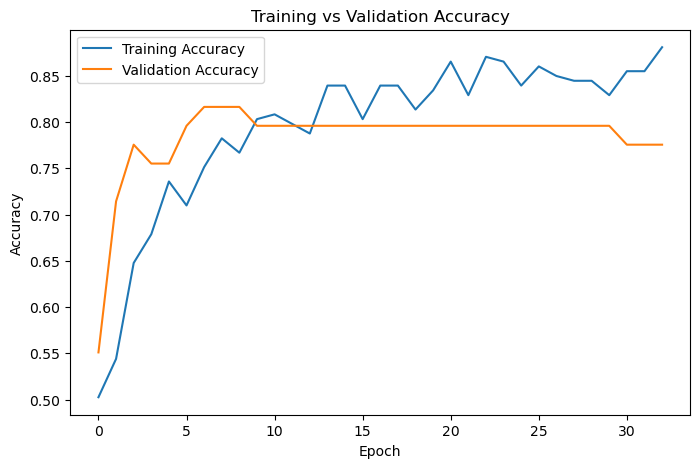

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig(FIGURES_PATH / "deep_learning_accuracy.png", dpi=300)

plt.show()

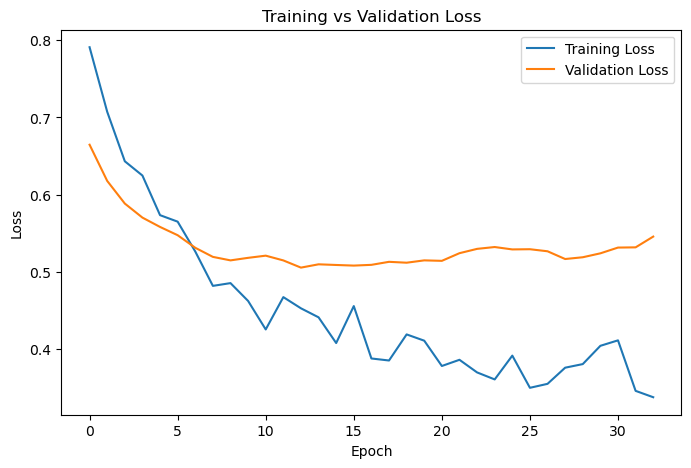

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig(FIGURES_PATH / "deep_learning_loss.png", dpi=300)

plt.show()

In [12]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8525
Precision: 0.8276
Recall   : 0.8571
F1 Score : 0.8421
ROC AUC  : 0.9524


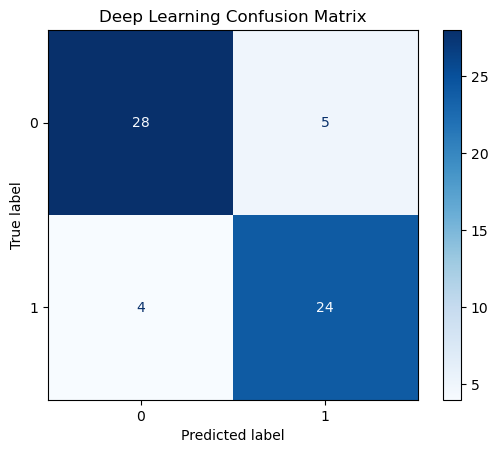

In [14]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Deep Learning Confusion Matrix")

plt.savefig(
    FIGURES_PATH / "deep_learning_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

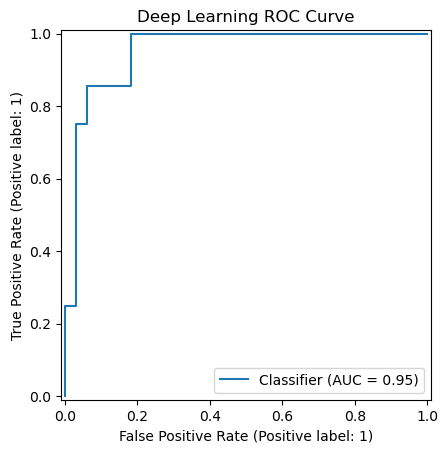

In [15]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Deep Learning ROC Curve")

plt.savefig(
    FIGURES_PATH / "deep_learning_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
model.save(MODEL_PATH / "deep_learning_model.keras")

print("Deep Learning model saved successfully.")

Deep Learning model saved successfully.


In [17]:
list(MODEL_PATH.iterdir())

[WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/models/.gitkeep'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/models/deep_learning_model.keras'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/models/heart_scaler.pkl'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/models/logistic_regression.pkl'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/models/random_forest.pkl'),
 WindowsPath('C:/Users/Syed SAAD ALI/Desktop/healthcare-ai-dissertation/models/xgboost.pkl')]

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Deep Learning"
    ],
    "Accuracy": [
        0.8689,
        0.9180,
        0.8852,
        0.8525
    ],
    "Precision": [
        0.8125,
        0.8710,
        0.8182,
        0.8276
    ],
    "Recall": [
        0.9286,
        0.9643,
        0.9643,
        0.8571
    ],
    "F1 Score": [
        0.8667,
        0.9153,
        0.8852,
        0.8421
    ],
    "ROC AUC": [
        0.9513,
        0.9535,
        0.9470,
        0.9524
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
1,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9535
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9470
3,Deep Learning,0.8525,0.8276,0.8571,0.8421,0.9524


In [21]:
comparison.to_csv(
    RESULTS_PATH / "model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [ ]:
## Interpretation of Results

The Deep Learning model achieved:

- Accuracy: 0.8525
- Precision: 0.8276
- Recall: 0.8571
- F1-score: 0.8421
- ROC-AUC: 0.9524

The model demonstrated strong discriminative ability as indicated by the high ROC-AUC score. However, its overall predictive performance
was lower than the Random Forest classifier developed in Notebook 03.

This finding suggests that for relatively small structured tabular datasets such as the Cleveland Heart Disease dataset,
classical ensemble methods may outperform deep neural networks. The results therefore support the selection of Random Forest
as the best-performing model for this study.

In [ ]:
## Conclusion

A Deep Learning model was successfully implemented and evaluated. Although the neural network achieved competitive predictive performance,
Random Forest remained the strongest overall classifier. The next notebook will focus on model explainability using SHAP to
understand how the best-performing model makes predictions.